# Exploración inicial DARWIN

En este fichero se realiza una exploración inicial de la base de datos DARWIN, del conjunto de todas sus variables.

## Descarga de los datos desde el repositorio

Se descargan los datos desde el repositorio *ucimlrepo*

In [1]:
import pandas as pd #  pandas
import seaborn as sns # seaborn
import matplotlib.pyplot as plt # matplotlib.pyplot
from pprint import pprint # pprint
from ucimlrepo import fetch_ucirepo # se importa fetch_ucilrepo
import os # os

In [2]:
# Se carga el dataset DARWIN
darwin = fetch_ucirepo(id=732)

In [ ]:
"""
CARGA DE BASE DE DATOS LOCAL 
- Emplear si el servidor UCI Machine Learning Repository se cae

# ruta local
ruta_darwin = os.path.expanduser("/Users/joseromerodegaetano/Desktop/DARWIN/DARWIN.csv") 

try:

    # Se carga el dataset
    df = pd.read_csv(ruta_darwin)

    x = df.drop(columns=['class']) # características
    y = df['class'] # clase

    print('Dataset DARWIN cargado correctamente') # dataset cargado

except FileNotFoundError: # cuando el archivo local no esté disponible
    print(f"No se encuentra el archivo .csv DARWIN en {ruta_darwin}")
"""

Dataset DARWIN cargado correctamente


## Metadatos
A continuación se visualizan los metadatos

In [3]:
# Se guardan los metadatos
metadatos = darwin.metadata
pprint(metadatos)

{'abstract': 'The DARWIN dataset includes handwriting data from 174 '
             'participants. The classification task consists in distinguishing '
             'Alzheimer’s disease patients from healthy people.',
 'additional_info': {'citation': 'N. D. Cilia, C. De Stefano, F. Fontanella, '
                                 'A. S. Di Freca, An experimental protocol to '
                                 'support cognitive impairment diagnosis by '
                                 'using handwriting analysis, Procedia '
                                 'Computer Science 141 (2018) 466–471. '
                                 'https://doi.org/10.1016/j.procs.2018.10.141\n'
                                 '\n'
                                 'N. D. Cilia, G. De Gregorio, C. De Stefano, '
                                 'F. Fontanella, A. Marcelli, A. Parziale, '
                                 'Diagnosing Alzheimer’s disease from online '
                                 'handwriting

## Exploración inicial de los datos

Se imprimen las primeras filas del dataset para comprobar la correcta importación del mismo.

In [5]:
# X (features)
x = darwin.data.features

# Y (targets)
y = darwin.data.targets

# Se concatena features y target en un mismo dataframe 'df'
df = pd.concat([x,y], axis=1)

# Se muestran las primeras 5 filas del df
df.head()

,ID,air_time1,disp_index1,gmrt_in_air1,gmrt_on_paper1,max_x_extension1,max_y_extension1,mean_acc_in_air1,mean_acc_on_paper1,mean_gmrt1,...,mean_jerk_in_air25,mean_jerk_on_paper25,mean_speed_in_air25,mean_speed_on_paper25,num_of_pendown25,paper_time25,pressure_mean25,pressure_var25,total_time25,class
0,id_1,5160,0.000013,120.804174,86.853334,957,6601,0.361800,0.217459,103.828754,...,0.141434,0.024471,5.596487,3.184589,71,40120,1749.278166,296102.7676,144605,P
1,id_2,51980,0.000016,115.318238,83.448681,1694,6998,0.272513,0.144880,99.383459,...,0.049663,0.018368,1.665973,0.950249,129,126700,1504.768272,278744.2850,298640,P
2,id_3,2600,0.000010,229.933997,172.761858,2333,5802,0.387020,0.181342,201.347928,...,0.178194,0.017174,4.000781,2.392521,74,45480,1431.443492,144411.7055,79025,P
3,id_4,2130,0.000010,369.403342,183.193104,1756,8159,0.556879,0.164502,276.298223,...,0.113905,0.019860,4.206746,1.613522,123,67945,1465.843329,230184.7154,181220,P
4,id_5,2310,0.000007,257.997131,111.275889,987,4732,0.266077,0.145104,184.636510,...,0.121782,0.020872,3.319036,1.680629,92,37285,1841.702561,158290.0255,72575,P


Se estudia el número de filas y columnas

In [6]:
# Número de filas y columnas
filas = df.shape[0] # filas
columnas = df.shape[1] # columnas
print(f"El dataset tiene {filas} filas y {columnas} columnas") # dimensión del dataset cargado

El dataset tiene 174 filas y 452 columnas


Se estudia el tipo de datos en nuestro dataset

In [7]:
# Tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Columns: 452 entries, ID to class
dtypes: float64(300), int64(150), object(2)
memory usage: 614.6+ KB


Se observa de nuevo que nuestro dataset tiene 174 entradas, ordenadas de 0 a 173.

452 columnas de ID a class, de las cuales 300 son tipo float, con números decimales, 150 tipo int, números enteros y 2 tipo objeto.

Para el tipo de variable, a continuación se imprimen las columnas y su tipo de variable.

In [8]:
# Tipo de var x columnas
print(df.dtypes)

ID                  object
air_time1            int64
disp_index1        float64
gmrt_in_air1       float64
gmrt_on_paper1     float64
                    ...   
paper_time25         int64
pressure_mean25    float64
pressure_var25     float64
total_time25         int64
class               object
Length: 452, dtype: object


Para facilitar el estudio, destacamos las columnas agrupadas por tipo int, float y object

In [9]:
# Columnas tipo int
cols_int = df.select_dtypes(include="int").columns
print("Columnas tipo int:", cols_int)

# Columnas tipo float
cols_float = df.select_dtypes(include="float").columns
print("Columnas tipo decimal:", cols_float)

# Columnas tipo objeto
cols_obj = df.select_dtypes(include="object").columns
print("Columnas tipo objeto:", cols_obj)

Columnas tipo int: Index(['air_time1', 'max_x_extension1', 'max_y_extension1', 'num_of_pendown1',
       'paper_time1', 'total_time1', 'air_time2', 'max_x_extension2',
       'max_y_extension2', 'num_of_pendown2',
       ...
       'max_y_extension24', 'num_of_pendown24', 'paper_time24', 'total_time24',
       'air_time25', 'max_x_extension25', 'max_y_extension25',
       'num_of_pendown25', 'paper_time25', 'total_time25'],
      dtype='object', length=150)
Columnas tipo decimal: Index(['disp_index1', 'gmrt_in_air1', 'gmrt_on_paper1', 'mean_acc_in_air1',
       'mean_acc_on_paper1', 'mean_gmrt1', 'mean_jerk_in_air1',
       'mean_jerk_on_paper1', 'mean_speed_in_air1', 'mean_speed_on_paper1',
       ...
       'gmrt_on_paper25', 'mean_acc_in_air25', 'mean_acc_on_paper25',
       'mean_gmrt25', 'mean_jerk_in_air25', 'mean_jerk_on_paper25',
       'mean_speed_in_air25', 'mean_speed_on_paper25', 'pressure_mean25',
       'pressure_var25'],
      dtype='object', length=300)
Columnas tipo ob

Descritos los tipos de variables, a continuación realizamos un análisis descriptivo básico por cada variable.

In [10]:
# Estadístia descriptiva
print(df.describe())

           air_time1  disp_index1  gmrt_in_air1  gmrt_on_paper1  \
count     174.000000   174.000000    174.000000      174.000000   
mean     5664.166667     0.000010    297.666685      200.504413   
std     12653.772746     0.000003    183.943181      111.629546   
min        65.000000     0.000002     28.734515       29.935835   
25%      1697.500000     0.000008    174.153023      136.524742   
50%      2890.000000     0.000009    255.791452      176.494494   
75%      4931.250000     0.000011    358.917885      234.052560   
max    109965.000000     0.000028   1168.328276      865.210522   

       max_x_extension1  max_y_extension1  mean_acc_in_air1  \
count        174.000000        174.000000        174.000000   
mean        1977.965517       7323.896552          0.416374   
std         1648.306365       2188.290512          0.381837   
min          754.000000        561.000000          0.067748   
25%         1362.500000       6124.000000          0.218209   
50%         1681.0

Seguidamente, se estudia si contamos con valores nulos o faltantes

In [11]:
# Valores nulos por columnas
print(df.isnull().sum())

ID                 0
air_time1          0
disp_index1        0
gmrt_in_air1       0
gmrt_on_paper1     0
                  ..
paper_time25       0
pressure_mean25    0
pressure_var25     0
total_time25       0
class              0
Length: 452, dtype: int64


Se observa que en todas las variables presentes no se encuentra ningún valor nulo.

A continuación, se estudia la proporción de pacientes con Alzheimer (P) vs Sanos (H), presentes en el dataset.

In [12]:
# Número pacientes 'P' y 'H'
conteo = df['class'].value_counts()
print(conteo)

# Proporción 'P' y 'H' en porcentaje
print(df['class'].value_counts(normalize=True))

class
P    89
H    85
Name: count, dtype: int64
class
P    0.511494
H    0.488506
Name: proportion, dtype: float64


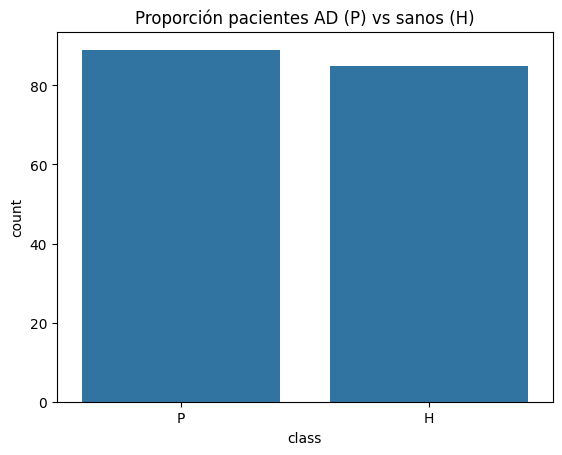

In [13]:
sns.countplot(x="class", data=df) # gráfico pacientes P vs H
plt.title("Proporción pacientes AD (P) vs sanos (H)") # título
plt.show() # se muestra el gráfico